In [1]:
# ==========================================
# 1. PREPARACIÓ DE L'ENTORN MODERN
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

using ITensors
using ITensorMPS
using Plots

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


En primer lugar, se genera el QTT de $n$ sitios correspondiente a un vector con $N=2^n$ elementos que tiene un fondo constante $C$, pero cuyo primer elemento vale $C+\epsilon_0$ y su último elemento vale $C+\epsilon_{N-1}$.

Los tres estados de los índices virtuales (enlaces) actúan como un autómata y significan lo siguiente:
* **Estado 1:** "Hasta ahora, la cadena viene siendo puramente de ceros ($|00\dots0\rangle$)."
* **Estado 2:** "La cadena ya se mezcló (contiene transiciones de ceros y unos) y representa el fondo constante."
* **Estado 3:** "Hasta ahora, la cadena viene siendo puramente de unos ($|11\dots1\rangle$)."

Los sitios $1$ a $n-1$ actúan como un detector lógico: solo registran si el camino de bits es homogéneo (ceros o unos) o si ya se mezcló. El sitio $n$ actúa como el evaluador numérico: lee el diagnóstico que le llega del resto de la cadena y asigna el valor físico real.

**El primer sitio** lee el primer bit y abre el camino correcto. Si es un cero, activa el Estado 1; si es un uno, activa el Estado 3. A cada estado le corresponde un elemento del vector fila que define el sitio:
$$M_1[0] = \begin{pmatrix} 1 & 0 & 0 \end{pmatrix}$$
$$M_1[1] = \begin{pmatrix} 0 & 0 & 1 \end{pmatrix}$$

**En los sitios intermedios**, las matrices de transferencia se rigen por el estado del que se proviene (filas) y el estado al que se pasa (columnas):

Si el bit leído es **0**, ya no puede mantenerse en el Estado 3 (se bloquea). El comportamiento se resume en la siguiente matriz:
* **Fila 1:** Si venía del Estado 1 y lee un 0, sigue en el Estado 1. La fila es: $\begin{pmatrix} 1 & 0 & 0 \end{pmatrix}$.
* **Fila 2:** Si ya venía mezclado (Estado 2) y lee un 0, sigue mezclado. La fila es: $\begin{pmatrix} 0 & 1 & 0 \end{pmatrix}$.
* **Fila 3:** Si venía puro de unos (Estado 3) y lee un 0, ¡se rompe la pureza! La matriz lo desvía automáticamente al canal mezclado (Estado 2). La fila es: $\begin{pmatrix} 0 & 1 & 0 \end{pmatrix}$.

Si el bit leído es **1**, ya no puede mantenerse en el Estado 1 (se bloquea). El comportamiento en este segundo caso es:
* **Fila 1:** Si venía del Estado 1 y lee un 1, ¡se rompe la pureza! Lo desvía al canal mezclado (Estado 2). La fila es: $\begin{pmatrix} 0 & 1 & 0 \end{pmatrix}$.
* **Fila 2:** Si ya venía mezclado (Estado 2) y lee un 1, sigue mezclado. La fila es: $\begin{pmatrix} 0 & 1 & 0 \end{pmatrix}$.
* **Fila 3:** Si venía del Estado 3 y lee un 1, sigue en el Estado 3. La fila es: $\begin{pmatrix} 0 & 0 & 1 \end{pmatrix}$.

**En el último sitio ($n$)**, el autómata colapsa en el valor numérico final mediante un vector columna:

Si el último bit es **0**:
* Si el enlace traía el Estado 1: Significa que todos los bits anteriores fueron 0, y como el último también es 0, estamos ante el mismísimo primer elemento del vector. El MPS devuelve $C+\epsilon_0$.
* Si el enlace traía el Estado 2 o 3: Significa que en algún punto hubo una mezcla (o venía de puros unos y cayó a cero al final). De cualquier forma, caímos en el interior, por lo que devuelve el fondo constante $C$.
Esto se traduce en la columna:
$$M_n[0] = \begin{pmatrix} C+\epsilon_0 \\ C \\ C \end{pmatrix}$$

Si el último bit es **1**:
* Si el enlace traía el Estado 1 o 2: Hubo mezcla en el camino (o venía de puros ceros y subió a uno al final). Devuelve el fondo constante $C$.
* Si el enlace traía el Estado 3: Todos los bits anteriores fueron 1, y como el último también es 1, estamos ante el último elemento del vector. El MPS devuelve $C+\epsilon_{N-1}$.
Esto se traduce en la columna:
$$M_n[1] = \begin{pmatrix} C \\ C \\ C+\epsilon_{N-1} \end{pmatrix}$$

In [8]:
function genera_qtt_constante_cc(n::Int, C::Float64, e0::Float64, eN1::Float64)
    sites = siteinds("Qubit", n)
    links = [Index(3, "Link,l=$i") for i in 1:(n-1)]
    mps = MPS(sites)
    
    # Sitio 1
    M1 = ITensor(sites[1], links[1])
    M1[sites[1]=>1, links[1]=>1] = 1.0
    M1[sites[1]=>2, links[1]=>3] = 1.0
    mps[1] = M1
    
    # Sitios Centrales
    for i in 2:(n-1)
        Mi = ITensor(links[i-1], sites[i], links[i])
        Mi[links[i-1]=>1, sites[i]=>1, links[i]=>1] = 1.0
        Mi[links[i-1]=>2, sites[i]=>1, links[i]=>2] = 1.0
        Mi[links[i-1]=>3, sites[i]=>1, links[i]=>2] = 1.0
        
        Mi[links[i-1]=>1, sites[i]=>2, links[i]=>2] = 1.0
        Mi[links[i-1]=>2, sites[i]=>2, links[i]=>2] = 1.0
        Mi[links[i-1]=>3, sites[i]=>2, links[i]=>3] = 1.0
        mps[i] = Mi
    end
    
    # Sitio N
    Mn = ITensor(links[n-1], sites[n])
    Mn[links[n-1]=>1, sites[n]=>1] = C+e0
    Mn[links[n-1]=>2, sites[n]=>1] = C
    Mn[links[n-1]=>3, sites[n]=>1] = C
    
    Mn[links[n-1]=>1, sites[n]=>2] = C
    Mn[links[n-1]=>2, sites[n]=>2] = C
    Mn[links[n-1]=>3, sites[n]=>2] = C+eN1
    mps[n] = Mn
    
    return mps, sites
end

# --- FUNCIÓN DE VERIFICACIÓN (PROYECCIÓN ELEMENTO A ELEMENTO) ---
function get_dense_vector(mps::MPS, sites)
    L = length(mps)
    N = 2^L
    vector_denso = zeros(Float64, N)
    
    for idx in 1:N
        # Convertir a binario ordenado de 1 a L
        bin_str = [string(c) for c in string(idx - 1, base=2, pad=L)]
        p_state = MPS(sites, bin_str)
        vector_denso[idx] = inner(mps, p_state)
    end
    return vector_denso
end

# --- EJECUCIÓN Y DEMOSTRACIÓN ---
n = 4 # Un espacio de Hilbert de 2^4 = 16 elementos
C, e0, eN1 = 1.0, 2.0, 0.5

mps, sites = genera_qtt_constante_cc(n, C, e0, eN1)
vector_denso = get_dense_vector(mps, sites)

# Imprimir el vector con sus etiquetas binarias para verificar
println("Vector completo generado de tamaño $(length(vector_denso)):")
println("-"^45)
for idx in 1:length(vector_denso)
    # Convertir el índice (1 a 2^n) a formato binario de n bits (ej: "0100")
    # Nota: Julia cuenta desde 1, restamos 1 para la base binaria
    bin_str = string(idx - 1, base=2, pad=n)
    
    # Formatear la salida para que sea fácil de leer
    println("| $bin_str ⟩ = ", vector_denso[idx])
end
println("-"^45)

Vector completo generado de tamaño 16:
---------------------------------------------
| 0000 ⟩ = 3.0
| 0001 ⟩ = 1.0
| 0010 ⟩ = 1.0
| 0011 ⟩ = 1.0
| 0100 ⟩ = 1.0
| 0101 ⟩ = 1.0
| 0110 ⟩ = 1.0
| 0111 ⟩ = 1.0
| 1000 ⟩ = 1.0
| 1001 ⟩ = 1.0
| 1010 ⟩ = 1.0
| 1011 ⟩ = 1.0
| 1100 ⟩ = 1.0
| 1101 ⟩ = 1.0
| 1110 ⟩ = 1.0
| 1111 ⟩ = 1.5
---------------------------------------------


### Representación QTT Exacta de Condiciones de Contorno

Al resolver una PDE unidimensional en un intervalo mediante métodos de diferencias finitas o elementos finitos, la incorporación de condiciones de contorno (como Dirichlet, Neumann o Robin) exige la modificación explícita de las fronteras algebraicas del sistema. Esto se traduce en alterar el primer y el último elemento del vector de carga o del término independiente $\mathbf{b}$.

Sin pérdida de generalidad, se considera un problema cuyo término fuente posee un comportamiento exponencial $f(x)=\mathcal{A} e^{-\gamma x}$. La representación matemática de su discretización en formato QTT genera un MPS con dimensión de enlace igual a 1 debido a la propiedad de factorizabilidad bit a bit de la función exponencial:

$$\mathbf{b}_{\text{interior}}(s_1, \dots, s_L)=\mathcal{A} \prod_{i=1}^L e^{-\gamma s_i 2^{i-1}}$$

Para imponer condiciones de contorno no homogéneas, es necesario sumar correcciones numéricas locales en los extremos del vector, denotadas por $\Delta_L$ para el contorno izquierdo y $\Delta_R$ para el contorno derecho. El vector de carga total modificado se define como:

$$\mathbf{b}_{\text{total}}=\mathbf{b}_{\text{interior}} + \Delta_L \mathbf{e}_0 + \Delta_R \mathbf{e}_{2^L-1}$$

donde $\mathbf{e}_0=|00\dots0\rangle$ y $\mathbf{e}_{2^L-1}=|11\dots1\rangle$ son los vectores unitarios correspondientes a los extremos en el formato QTT.

Por el teorema de la suma de rangos tensoriales, la adición de estas tres estructuras independientes da lugar a un tren de tensores cuya dimensión de enlace interna máxima es estrictamente 3. Para construir este MPS de forma exacta, no se utilizan transiciones de estado, sino **tres canales virtuales paralelos e independientes**:

* **Canal 1 (Exponencial base):** Propaga el factor $e^{-\gamma x}$ de manera incondicional para cualquier combinación de bits.
* **Canal 2 (Contorno izquierdo):** Rastrea y propaga la condición $\Delta_L$. Exige una trayectoria puramente de ceros ($|00\dots0\rangle$). Cualquier bit en 1 aniquila este canal.
* **Canal 3 (Contorno derecho):** Rastrea y propaga la condición $\Delta_R$. Exige una trayectoria puramente de unos ($|11\dots1\rangle$). Cualquier bit en 0 aniquila este canal.

Definiendo el factor de escala local para cada sitio como $\lambda_i=e^{-\gamma 2^{i-1}}$ y el valor total de la amplitud exponencial como $\Lambda=\mathcal{A}\prod_{i=1}^L \lambda_i$, los tensores QTT exactos de $\mathbf{b}_{\text{total}}$ se especifican a continuación:

**1. Nodo frontera izquierdo ($i=1$):** Vector fila que inicializa los canales. Si es 0, inicia la exponencial y la perturbación izquierda. Si es 1, inicia la exponencial y la perturbación derecha.

$$A^{[1]0}=\begin{pmatrix}1 & 1 & 0\end{pmatrix}$$

$$A^{[1]1}=\begin{pmatrix}\lambda_1 & 0 & 1\end{pmatrix}$$

**2. Nodos interiores del dominio ($1 < i < L$):** Matrices de transferencia diagonales de 3x3 que actúan como filtros estrictos. El canal 1 siempre sobrevive. El canal 2 solo sobrevive si entra un 0. El canal 3 solo sobrevive si entra un 1.

$$A^{[i]0}=\begin{pmatrix}1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 0\end{pmatrix}$$

$$A^{[i]1}=\begin{pmatrix}\lambda_i & 0 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 1\end{pmatrix}$$

**3. Nodo frontera derecho ($i=L$):** Vector columna que unifica los canales y aplica las amplitudes finales ($\mathcal{A}$ para la exponencial, $\Delta_L$ o $\Delta_R$ para los contornos que hayan sobrevivido).

$$A^{[L]0}=\begin{pmatrix}\mathcal{A} \\ \Delta_L \\ 0\end{pmatrix}$$

$$A^{[L]1}=\begin{pmatrix}\mathcal{A}\lambda_L \\ 0 \\ \Delta_R\end{pmatrix}$$

---

### Nota de verificación matemática

* **Caso $|00\dots0\rangle$:** El producto de matrices mantiene vivos los canales 1 y 2. El colapso final es la suma de ambos: $1 \cdot 1 \dots 1 \cdot \mathcal{A} + 1 \cdot 1 \dots 1 \cdot \Delta_L + 0 = \mathcal{A} + \Delta_L$.
* **Caso $|11\dots1\rangle$:** El producto mantiene vivos los canales 1 y 3. El colapso final es: $\lambda_1 \cdot \lambda_2 \dots \lambda_{L-1} \cdot \mathcal{A}\lambda_L + 0 + 1 \cdot 1 \dots 1 \cdot \Delta_R = \Lambda + \Delta_R$.
* **Casos mixtos:** Cualquier alternancia de bits (por ejemplo $0 \to 1$ o $1 \to 0$) introduce un multiplicador cero en los canales 2 y 3 dentro de los nodos intermedios, aniquilándolos definitivamente. Únicamente sobrevive el Canal 1, que acumula rigurosamente el producto multiplicativo $\mathcal{A} \prod \lambda_i$ correspondiente a $\mathbf{b}_{\text{interior}}$ sin verse afectado por las perturbaciones de los extremos.

In [11]:
function genera_qtt_exponencial_cc(L::Int, A_amp::Float64, γ::Float64, ΔL::Float64, ΔR::Float64)
sites = siteinds("Qubit", L)
    links = [Index(3, "Link,l=$i") for i in 1:(L-1)]
    mps = MPS(sites)
    
    λ = [exp(-γ * 2^(i-1)) for i in 1:L]
    
    # --- SITIO 1 ---
    A1 = ITensor(sites[1], links[1])
    # Canal 1: Exponencial pura | Canal 2: Delta en 0 | Canal 3: Delta en 2^L - 1
    
    # Si bit = 0
    A1[sites[1]=>1, links[1]=>1] = 1.0
    A1[sites[1]=>1, links[1]=>2] = 1.0   # Activa el canal de la delta izquierda
    
    # Si bit = 1
    A1[sites[1]=>2, links[1]=>1] = λ[1]
    A1[sites[1]=>2, links[1]=>3] = 1.0   # Activa el canal de la delta derecha
    mps[1] = A1
    
    # --- SITIOS CENTRALES ---
    for i in 2:(L-1)
        Ai = ITensor(links[i-1], sites[i], links[i])
        
        # Si bit = 0 (propaga la exponencial y la delta izquierda; mata la derecha)
        Ai[links[i-1]=>1, sites[i]=>1, links[i]=>1] = 1.0
        Ai[links[i-1]=>2, sites[i]=>1, links[i]=>2] = 1.0
        
        # Si bit = 1 (propaga la exponencial y la delta derecha; mata la izquierda)
        Ai[links[i-1]=>1, sites[i]=>2, links[i]=>1] = λ[i]
        Ai[links[i-1]=>3, sites[i]=>2, links[i]=>3] = 1.0
        
        mps[i] = Ai
    end
    
    # --- SITIO L (Cobrador/Sumador final) ---
    AL = ITensor(links[L-1], sites[L])
    
    # Si bit = 0
    AL[links[L-1]=>1, sites[L]=>1] = A_amp         # Cierra exponencial
    AL[links[L-1]=>2, sites[L]=>1] = ΔL            # Cierra delta izquierda
    
    # Si bit = 1
    AL[links[L-1]=>1, sites[L]=>2] = A_amp * λ[L]  # Cierra exponencial
    AL[links[L-1]=>3, sites[L]=>2] = ΔR            # Cierra delta derecha
    
    mps[L] = AL
    return mps, sites
end

genera_qtt_exponencial_cc (generic function with 1 method)

In [12]:
using Printf
# --- EJECUCIÓN DEL EJEMPLO ---
L = 4  # N = 16 puntos de malla
A_amp = 5.0
γ = 0.2
ΔL = 100.0  # Gran perturbación en Dirichlet izquierdo
ΔR = -50.0  # Gran perturbación en Dirichlet derecho

mps, sites = genera_qtt_exponencial_cc(L, A_amp, γ, ΔL, ΔR)
v_total = get_dense_vector(mps, sites)

# Imprimir resultados analíticos vs MPS
println("Resultados de la simulación QTT (L = $L):")
println("-"^60)
for idx in 1:length(v_total)
    bin_str = string(idx - 1, base=2, pad=L)
    
    # Calcular analíticamente el valor esperado de la exponencial pura
    # Nota: El exponente mapea los bits de menor a mayor significancia (QTT estándar)
    bits = [parse(Int, c) for c in bin_str]
    x_val = sum(bits[i] * 2^(i-1) for i in 1:L)
    val_exp_puro = A_amp * exp(-γ * x_val)
    
    # Sumar correcciones si estamos en los extremos reales del vector
    val_esperado = val_exp_puro
    if idx == 1
        val_esperado += ΔL
    elseif idx == length(v_total)
        val_esperado += ΔR
    end
    
    @printf("| %s ⟩ | QTT-MPS: %10.4f | Analítico Esperado: %10.4f |\n", bin_str, v_total[idx], val_esperado)
end
println("-"^60)

Resultados de la simulación QTT (L = 4):
------------------------------------------------------------
| 0000 ⟩ | QTT-MPS:   105.0000 | Analítico Esperado:   105.0000 |
| 0001 ⟩ | QTT-MPS:     1.0095 | Analítico Esperado:     1.0095 |
| 0010 ⟩ | QTT-MPS:     2.2466 | Analítico Esperado:     2.2466 |
| 0011 ⟩ | QTT-MPS:     0.4536 | Analítico Esperado:     0.4536 |
| 0100 ⟩ | QTT-MPS:     3.3516 | Analítico Esperado:     3.3516 |
| 0101 ⟩ | QTT-MPS:     0.6767 | Analítico Esperado:     0.6767 |
| 0110 ⟩ | QTT-MPS:     1.5060 | Analítico Esperado:     1.5060 |
| 0111 ⟩ | QTT-MPS:     0.3041 | Analítico Esperado:     0.3041 |
| 1000 ⟩ | QTT-MPS:     4.0937 | Analítico Esperado:     4.0937 |
| 1001 ⟩ | QTT-MPS:     0.8265 | Analítico Esperado:     0.8265 |
| 1010 ⟩ | QTT-MPS:     1.8394 | Analítico Esperado:     1.8394 |
| 1011 ⟩ | QTT-MPS:     0.3714 | Analítico Esperado:     0.3714 |
| 1100 ⟩ | QTT-MPS:     2.7441 | Analítico Esperado:     2.7441 |
| 1101 ⟩ | QTT-MPS:     0.5540 | Analíti

### Construcción Híbrida del MPS: Fuente Gaussiana y Condiciones de Contorno

A diferencia del fondo constante o la caída exponencial, el término fuente Gaussiano $Q(x) = Q_0 e^{-\frac{(x-\mu)^2}{2\sigma^2}}$ no posee una factorizabilidad exacta bit a bit en el espacio QTT. La presencia del término cruzado en el desarrollo del exponente cuadrado altera la independencia lineal de los bits, lo que impide construir un autómata lógico analítico de dimensión de enlace 1.

Para resolver este sistema, empleamos un **enfoque híbrido** que combina la compresión numérica del núcleo y la inserción analítica de las fronteras en tres pasos:

**1. Compresión Numérica (SVD) de la Gaussiana:**
Para el perfil general de la fuente, se evalúa la función Gaussiana en el dominio discretizado y se moldea (`reshape`) en un tensor multidimensional de orden $L$, con dimensión local 2. Sobre este tensor denso se aplica una Descomposición en Valores Singulares (SVD) sucesiva con un umbral de truncamiento (`cutoff`). Este proceso numérico descarta las correlaciones irrelevantes y comprime la información en un MPS, logrando representar la curva continua con una dimensión de enlace baja y acotada (típicamente $\chi \approx 4$).

**2. Construcción Analítica de las Fronteras (Rango 1):**
Las modificaciones impuestas por las condiciones de contorno en los extremos del dominio ($\Delta_L$ y $\Delta_R$) actúan exclusivamente sobre el primer y último nodo de la malla espacial. En la base lógica QTT, estos nodos corresponden a los vectores de estado puros $|00\dots0\rangle$ y $|11\dots1\rangle$. Al ser puramente homogéneos, se construyen directamente como trenes de tensores exactos con dimensión de enlace $\chi = 1$, introduciendo la amplitud del salto térmico en el primer tensor de cada cadena.

**3. Superposición Aditiva y Truncamiento mediate SVD:**
Finalmente, se aprovecha el álgebra lineal nativa de las redes tensoriales para ensamblar el vector final modificado:
$$\mathbf{b}_{\text{total}} = \mathbf{b}_{\text{gauss}} + \Delta_L |00\dots0\rangle + \Delta_R |11\dots1\rangle$$
Al ejecutar la suma de estos tensores, el algoritmo fusiona las dimensiones de enlace y aplica un SVD de limpieza en un solo barrido. Por el teorema de la suma de rangos, la complejidad del tensor final se mantiene estrictamente limitada a $\chi_{\text{total}} \le \chi_{\text{gauss}} + 2$, fusionando a la perfección una forma suave (Gaussiana numérica) con singularidades abruptas (saltos de contorno analíticos) en un único objeto matemático eficiente.

--- Dimensiones Máximas de Enlace (χ) ---
χ Gaussiana Pura : 4
χ Total (Con CC) : 4
-----------------------------------------



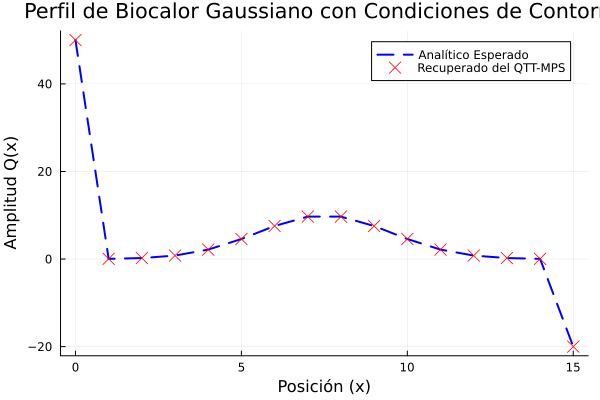

In [17]:
using Plots

function genera_qtt_gaussiana_cc(L::Int, Q0::Float64, μ::Float64, σ::Float64, ΔL::Float64, ΔR::Float64; cutoff::Float64=1e-8)
    sites = siteinds("Qubit", L)
    N = 2^L
    
    # ---------------------------------------------------------
    # 1. Construcción del MPS de la fuente Gaussiana
    # ---------------------------------------------------------
    vec_gauss = [Q0 * exp(-((x - μ)^2) / (2 * σ^2)) for x in 0:(N-1)]
    arr_gauss = reshape(vec_gauss, ntuple(x -> 2, L)...)
    
    T_gauss = ITensor(arr_gauss, sites...)
    mps_gauss = MPS(T_gauss, sites; cutoff=cutoff)
    
    # ---------------------------------------------------------
    # 2. Construcción de los MPS de Contorno (Rango 1)
    # ---------------------------------------------------------
    mps_L = MPS(sites, "0") 
    mps_L[1] *= ΔL  
    
    mps_R = MPS(sites, "1")
    mps_R[1] *= ΔR  
    
    # ---------------------------------------------------------
    # 3. Superposición Aditiva
    # ---------------------------------------------------------
    mps_total = +(mps_gauss, mps_L; cutoff=cutoff)
    mps_total = +(mps_total, mps_R; cutoff=cutoff)
    
    return mps_total, sites, mps_gauss
end

# --- EJECUCIÓN Y PRUEBA ---
L = 4
Q0 = 10.0
μ = 7.5      
σ = 2.0      
ΔL = 50.0    
ΔR = -20.0   

mps_final, sites, mps_gauss_puro = genera_qtt_gaussiana_cc(L, Q0, μ, σ, ΔL, ΔR)

println("--- Dimensiones Máximas de Enlace (χ) ---")
println("χ Gaussiana Pura : ", maxlinkdim(mps_gauss_puro))
println("χ Total (Con CC) : ", maxlinkdim(mps_final))
println("-----------------------------------------\n")

# ---------------------------------------------------------
# 4. Reconstrucción y Visualización (NUEVO)
# ---------------------------------------------------------
N = 2^L
x_vals = 0:(N-1)

# A. Generar vector QTT evaluando el MPS en cada estado lógico
vec_qtt = zeros(Float64, N)
for x in x_vals
    # Convertimos el entero a binario y lo INVERTIMOS para que coincida con el tensor
    estado_binario = reverse(string(x, base=2, pad=L)) 
    
    vector_estados = [string(bit) for bit in estado_binario]
    
    estado_mps = MPS(sites, vector_estados)
    vec_qtt[x+1] = inner(estado_mps, mps_final)
end

# B. Generar vector analítico esperado
vec_ana = [Q0 * exp(-((x - μ)^2) / (2 * σ^2)) for x in x_vals]
vec_ana[1] += ΔL
vec_ana[end] += ΔR

# C. Graficar ambos
plt = plot(x_vals, vec_ana, 
    label="Analítico Esperado", 
    linewidth=2, 
    color=:blue, 
    style=:dash)

scatter!(plt, x_vals, vec_qtt, 
    label="Recuperado del QTT-MPS", 
    markersize=6, 
    color=:red, 
    marker=:x)

plot!(plt, 
    title="Perfil de Biocalor Gaussiano con Condiciones de Contorno",
    xlabel="Posición (x)",
    ylabel="Amplitud Q(x)",
    legend=:topright,
    grid=true)

display(plt)